# `simulateIterative` : prototype d'une simulation conditionnelle matrice-libre

> **⚠️ Ceci est un prototype exploratoire, en numpy pur, pas une documentation
> d'une fonctionnalité existante.** `simulateIterative` **n'existe pas**
> aujourd'hui dans libKriging : `Kriging::simulate()` lève explicitement une
> erreur sur un modèle ajusté avec `objective="LL"` (matrice-libre, voir
> `check_not_iterative_light("simulate")` dans `Kriging.cpp`). Ce notebook
> répond à une question de faisabilité : **peut-on construire une variante
> matrice-libre de `simulate()`, qui ne factorise ni ne stocke jamais de
> matrice dense `n_o × n_o` ou `n_n × n_n` ?** La réponse, validée
> numériquement ci-dessous, est oui — en réutilisant telles quelles les deux
> briques déjà présentes dans le projet : le gradient conjugué (CG) de
> `predictIterative`, et l'échantillonnage par quadrature de Lanczos (SLQ)
> déjà utilisé pour `log|R|` dans `LLIterative`, simplement appliqué avec
> $f=\sqrt{\cdot}$ au lieu de $f=\log$.
>
> Ce notebook est le compagnon exploratoire de
> [lliterative_vs_cholesky.ipynb](lliterative_vs_cholesky.ipynb) (le fit) et
> [predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb)
> (la prédiction) — mais contrairement à ceux-ci, il ne documente **aucun
> code C++ existant** : tout le calcul ci-dessous est un prototype numpy
> autonome, écrit pour valider l'idée avant une éventuelle implémentation.

## 1. Ce que fait `simulate()` aujourd'hui (Cholesky, exact)

Pour mémoire, `Kriging::simulate_impl` (dans `KrigingImpl.cpp`) tire des
réalisations conditionnelles en deux temps, en réutilisant le facteur de
Cholesky `m_T` de $R_{oo}$ déjà calculé au `fit` :

$$
\hat y_n = F_n \hat\beta + R_{on}^{*T} m_z
\qquad\text{avec}\qquad
R_{on}^* = L^{-1} R_{on}
$$

$$
\Sigma_{n\mid o} = \underbrace{R_{nn} - R_{on}^{*T} R_{on}^*}_{\text{covariance a posteriori, moyenne connue}}
\;+\; \underbrace{E_n^\circ {E_n^\circ}^T}_{\text{incertitude supplementaire due a }\hat\beta \text{ (GLS)}}
$$

$$
y_n = \hat y_n + L_{\Sigma} \, \varepsilon, \qquad L_\Sigma = \mathrm{chol}(\Sigma_{n\mid o}), \qquad \varepsilon \sim \mathcal N(0, I_{n_n})
$$

Deux coûts cubiques/quadratiques bien identifiés :

1. **`Rstar_on = L^{-1} @ R_on`** : une résolution triangulaire $O(n_o^2 \cdot n_n)$
   qui nécessite $L$, donc la factorisation $O(n_o^3)$ de $R_{oo}$ au `fit`
   — exactement le coût que `predictIterative` évite déjà via CG.
2. **`LSigma_nKo = chol(Sigma_nKo)`** : une factorisation dense
   $O(n_n^3)$ — un coût **nouveau**, propre à `simulate()`, qui n'existe pas
   dans `predict()` (`predict` ne calcule que la diagonale/quelques colonnes
   de $\Sigma_{n\mid o}$, jamais sa racine carrée complète).

Un `simulateIterative` matrice-libre doit donc remplacer **les deux** : (1)
par CG (déjà fait ailleurs), et (2) par une méthode qui échantillonne
$\mathcal N(0,\Sigma_{n\mid o})$ sans jamais factoriser $\Sigma_{n\mid o}$ —
c'est le sujet de ce notebook. Pour rester concentré sur cette mécanique
CG+Lanczos (le vrai inconnu), on illustre avec le **krigeage simple**
(moyenne nulle connue, pas de terme $E_n^\circ {E_n^\circ}^T$) : l'algèbre de
la tendance (GLS) est la même que celle déjà validée dans
`predictiterative_vs_cholesky.ipynb` et n'apporte rien de nouveau ici.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

rng_global = np.random.default_rng(0)

def matern5_2(d, theta):
    r = np.abs(d) / theta
    s5 = np.sqrt(5.0)
    return (1 + s5 * r + 5 * r**2 / 3) * np.exp(-s5 * r)

def lanczos(Rmul, z, k):
    # Lanczos avec reorthogonalisation complete (meme construction que la SLQ
    # de production utilisee pour log|R| dans LLIterative).
    n = z.shape[0]
    V = np.zeros((n, k))
    alpha = np.zeros(k)
    beta = np.zeros(k - 1)
    v_prev = np.zeros(n)
    beta_prev = 0.0
    v = z / np.linalg.norm(z)
    for j in range(k):
        V[:, j] = v
        w = Rmul(v) - beta_prev * v_prev
        a = v @ w
        alpha[j] = a
        w = w - a * v
        w = w - V[:, :j+1] @ (V[:, :j+1].T @ w)
        w = w - V[:, :j+1] @ (V[:, :j+1].T @ w)  # deuxieme passe (Gram-Schmidt modifie)
        b = np.linalg.norm(w)
        if j < k - 1:
            beta[j] = b
        if b < 1e-13:
            k_eff = j + 1
            return V[:, :k_eff], alpha[:k_eff], beta[:max(k_eff-1, 0)]
        v_prev = v
        v = w / b
        beta_prev = b
    return V, alpha, beta

def apply_matrix_function(Rmul, z, k, func):
    # Approxime func(A) @ z par quadrature de Lanczos. Avec func=np.log et A=R,
    # c'est exactement la SLQ du log-determinant de LLIterative ; ici on prend
    # func=np.sqrt pour obtenir un tirage gaussien matrice-libre.
    znorm = np.linalg.norm(z)
    if znorm == 0:
        return np.zeros_like(z)
    V, alpha, beta = lanczos(Rmul, z, k)
    T = np.diag(alpha) + np.diag(beta, 1) + np.diag(beta, -1)
    w, Q = np.linalg.eigh(T)
    coeffs = Q[0, :] * func(w)
    fT_e1 = Q @ coeffs
    return znorm * (V @ fT_e1)

def cg_solve(Amul, b, tol=1e-10, max_iter=200):
    # Gradient conjugue standard (memes formules que LLIterative/predictIterative;
    # b est petit dans tout ce notebook donc pas besoin de restart periodique).
    x = np.zeros_like(b)
    r = b - Amul(x)
    p = r.copy()
    rs_old = r @ r
    bnorm = max(1.0, np.linalg.norm(b))
    if np.sqrt(rs_old) < tol * bnorm:
        return x
    for _ in range(max_iter):
        Ap = Amul(p)
        alpha = rs_old / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = r @ r
        if np.sqrt(rs_new) < tol * bnorm:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x


## 2. Rappel : échantillonnage matrice-libre INCONDITIONNEL

Avant la simulation conditionnelle, la brique de base : tirer
$z \sim \mathcal N(0, R)$ sans factoriser $R$, via
`apply_matrix_function(Rmul, \varepsilon, k, \sqrt{\cdot})`. On reprend
l'exemple des notebooks précédents (grille régulière, Matern 5/2,
$\theta=0.2$, conditionnement "raisonnable mais pas trivial").

In [2]:

n = 30
X = np.linspace(0.02, 0.98, n).reshape(-1, 1)
D = np.abs(X - X.T)
theta = 0.2
R = matern5_2(D, theta)
print(f"cond(R) = {np.linalg.cond(R):.3e}")

L = np.linalg.cholesky(R)
Rmul = lambda v: R @ v


cond(R) = 1.643e+05


In [3]:

print("=== Test 1 : invariant ||M z||^2 = z^T R z (par tirage) ===")
z_test_u = rng_global.standard_normal(n)
true_quad_u = z_test_u @ Rmul(z_test_u)
for k in [2, 5, 10, 15, 20, 25, 30]:
    sample_k = apply_matrix_function(Rmul, z_test_u, k, np.sqrt)
    approx_quad = sample_k @ sample_k
    print(f"  lanczos_steps={k:3d}   erreur relative = {abs(approx_quad-true_quad_u)/abs(true_quad_u):.2e}")


=== Test 1 : invariant ||M z||^2 = z^T R z (par tirage) ===
  lanczos_steps=  2   erreur relative = 4.13e-16
  lanczos_steps=  5   erreur relative = 1.38e-16
  lanczos_steps= 10   erreur relative = 1.79e-15
  lanczos_steps= 15   erreur relative = 1.79e-15
  lanczos_steps= 20   erreur relative = 1.51e-15
  lanczos_steps= 25   erreur relative = 2.61e-15
  lanczos_steps= 30   erreur relative = 6.88e-16


=== Test 2 : covariance empirique vs R, en fonction de lanczos_steps ===
  reference (Cholesky exact) : erreur relative Frobenius = 0.0410  (plancher Monte-Carlo)
  lanczos_steps=  3 : erreur relative Frobenius = 0.0563


  lanczos_steps=  5 : erreur relative Frobenius = 0.0391


  lanczos_steps=  8 : erreur relative Frobenius = 0.0370


  lanczos_steps= 12 : erreur relative Frobenius = 0.0370


  lanczos_steps= 16 : erreur relative Frobenius = 0.0370


  lanczos_steps= 20 : erreur relative Frobenius = 0.0370


  lanczos_steps= 25 : erreur relative Frobenius = 0.0370


  lanczos_steps= 30 : erreur relative Frobenius = 0.0370


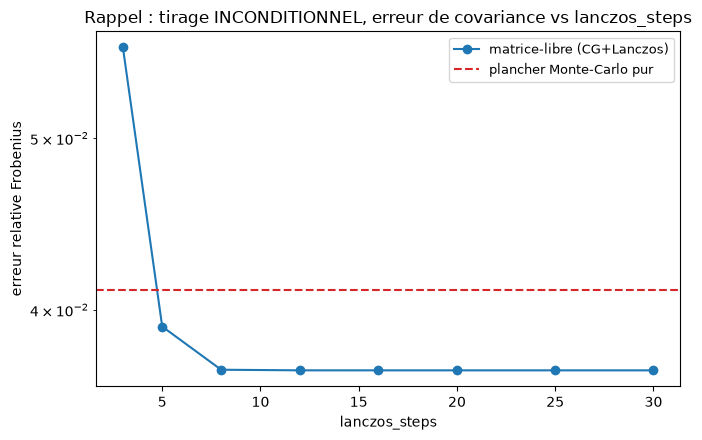

In [4]:

print("=== Test 2 : covariance empirique vs R, en fonction de lanczos_steps ===")
n_samples = 3000
Z_u = rng_global.standard_normal((n, n_samples))

samples_exact_u = L @ Z_u
cov_exact_u = (samples_exact_u @ samples_exact_u.T) / n_samples
err_exact_u = np.linalg.norm(cov_exact_u - R) / np.linalg.norm(R)
print(f"  reference (Cholesky exact) : erreur relative Frobenius = {err_exact_u:.4f}  (plancher Monte-Carlo)")

lanczos_grid_u = [3, 5, 8, 12, 16, 20, 25, 30]
errs_cov_u = []
for k in lanczos_grid_u:
    samples_k = np.zeros((n, n_samples))
    for i in range(n_samples):
        samples_k[:, i] = apply_matrix_function(Rmul, Z_u[:, i], k, np.sqrt)
    cov_k = (samples_k @ samples_k.T) / n_samples
    err = np.linalg.norm(cov_k - R) / np.linalg.norm(R)
    errs_cov_u.append(err)
    print(f"  lanczos_steps={k:3d} : erreur relative Frobenius = {err:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(lanczos_grid_u, errs_cov_u, 'o-', color='tab:blue', label='matrice-libre (CG+Lanczos)')
ax.axhline(err_exact_u, color='tab:red', ls='--', label='plancher Monte-Carlo pur')
ax.set_xlabel('lanczos_steps'); ax.set_ylabel('erreur relative Frobenius')
ax.set_title("Rappel : tirage INCONDITIONNEL, erreur de covariance vs lanczos_steps")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


## 3. Simulation CONDITIONNELLE : la formule matrice-libre

On veut maintenant tirer $y_n \mid y_o \sim \mathcal N(\hat y_n, \Sigma_{n\mid o})$
(krigeage simple, moyenne nulle) avec :

$$
\hat y_n = R_{no} R_{oo}^{-1} y_o
\qquad
\Sigma_{n\mid o} = R_{nn} - R_{no} R_{oo}^{-1} R_{on}
$$

**Idée matrice-libre** : $R_{oo}^{-1}(\cdot)$ se remplace par CG partout (comme
`predictIterative`), et la racine carrée de $\Sigma_{n\mid o}$ se remplace par
la même quadrature de Lanczos qu'en §2, appliquée à l'oracle matrice-vecteur

$$
v \;\longmapsto\; \Sigma_{n\mid o}\, v = R_{nn} v - R_{no}\,\underbrace{\mathrm{CG}(R_{oo}, R_{on} v)}_{\text{1 resolution CG par etape de Lanczos}}
$$

Aucune matrice $n_o \times n_o$ n'est jamais factorisée, et $\Sigma_{n\mid o}$
elle-même n'est jamais formée ni factorisée — seuls des produits
matrice-vecteur et des résolutions CG de taille $n_o$ interviennent.

Exemple choisi **délibérément avec un grand trou d'observation** : deux
paquets de points observés séparés par un large intervalle vide. Une grille
régulière sur tout $[0,1]$ laisse une incertitude a posteriori quasi nulle
partout (spectre de $\Sigma_{n\mid o}$ qui s'effondre en 1-2 pas de Lanczos,
peu instructif) ; le trou crée une vraie bosse d'incertitude et rend le "fan
chart" et la convergence en `lanczos_steps` beaucoup plus parlants.

In [5]:

n_o = 20
n_n = 90
X_o = np.concatenate([np.linspace(0.03, 0.33, n_o // 2),
                       np.linspace(0.67, 0.97, n_o - n_o // 2)]).reshape(-1, 1)
X_n = np.linspace(0.0, 1.0, n_n).reshape(-1, 1)
theta = 0.2

D_oo = np.abs(X_o - X_o.T)
D_nn = np.abs(X_n - X_n.T)
D_on = np.abs(X_o - X_n.T)

R_oo = matern5_2(D_oo, theta)
R_nn = matern5_2(D_nn, theta)
R_on = matern5_2(D_on, theta)
R_no = R_on.T

print(f"cond(R_oo) = {np.linalg.cond(R_oo):.3e}   (n_o={n_o})")

L_oo = np.linalg.cholesky(R_oo)
Roo_mul = lambda v: R_oo @ v

y_o = L_oo @ rng_global.standard_normal(n_o)  # un vrai tirage GP, pas une fonction synthetique


cond(R_oo) = 8.281e+04   (n_o=20)


In [6]:

# Reference EXACTE (equivalente a simulate_impl, cas moyenne nulle)
alpha_exact = np.linalg.solve(R_oo, y_o)
yhat_n_exact = R_no @ alpha_exact
RooInv_Ron = np.linalg.solve(R_oo, R_on)
Sigma_nKo_exact = R_nn - R_no @ RooInv_Ron
Sigma_nKo_exact = 0.5 * (Sigma_nKo_exact + Sigma_nKo_exact.T)
L_Sigma_exact = np.linalg.cholesky(Sigma_nKo_exact + 1e-12 * np.eye(n_n))

# Racine carree SYMETRIQUE (unique, via eigendecomposition) -- c'est CELLE-CI
# que Lanczos approxime, PAS la factorisation de Cholesky (voir §4.2 plus bas).
w_sigma, V_sigma = np.linalg.eigh(Sigma_nKo_exact)
w_sigma = np.clip(w_sigma, 0, None)
S_Sigma_exact = V_sigma @ np.diag(np.sqrt(w_sigma)) @ V_sigma.T
print("valeurs propres de Sigma_n|o : min = %.3e, max = %.3e, cond = %.3e"
      % (w_sigma.min(), w_sigma.max(), w_sigma.max()/max(w_sigma.min(), 1e-300)))


valeurs propres de Sigma_n|o : min = 7.829e-08, max = 2.023e+00, cond = 2.584e+07


In [7]:

cg_tol = 1e-10

def sigma_nko_matvec_impl(v, cg_tol=cg_tol, cg_max_iter=200):
    w = R_on @ v
    x = cg_solve(Roo_mul, w, tol=cg_tol, max_iter=cg_max_iter)
    return R_no @ x

def yhat_n_iterative(cg_tol=cg_tol, cg_max_iter=200):
    alpha = cg_solve(Roo_mul, y_o, tol=cg_tol, max_iter=cg_max_iter)
    return R_no @ alpha

def sigma_matvec_tight(v):
    return R_nn @ v - sigma_nko_matvec_impl(v, cg_tol=1e-12, cg_max_iter=300)

def simulate_iterative_conditional(seed, lanczos_steps, cg_tol=cg_tol):
    rng = np.random.default_rng(seed)
    yhat_n = yhat_n_iterative(cg_tol=cg_tol)
    z = rng.standard_normal(n_n)
    def sigma_matvec(v):
        return R_nn @ v - sigma_nko_matvec_impl(v, cg_tol=cg_tol)
    s = apply_matrix_function(sigma_matvec, z, lanczos_steps, np.sqrt)
    return yhat_n + s, yhat_n


## 4. Validation

### 4.1 Moyenne a posteriori : CG vs Cholesky exact

In [8]:

yhat_n_cg = yhat_n_iterative(cg_tol=1e-12, cg_max_iter=300)
err_mean = np.abs(yhat_n_cg - yhat_n_exact).max()
print(f"max|yhat_n(CG) - yhat_n(Cholesky)| = {err_mean:.3e}")


max|yhat_n(CG) - yhat_n(Cholesky)| = 2.043e-13


### 4.2 Piège : quel "exact" comparer au vecteur simulé ?

Un premier réflexe est de comparer, pour un $z$ **fixé**, le vecteur simulé
matrice-libre $M_k z$ au vecteur "de référence" $L_\Sigma z$ (Cholesky de
$\Sigma_{n\mid o}$). **C'est la mauvaise comparaison** : $L_\Sigma$ et la
racine carrée symétrique $S=\Sigma_{n\mid o}^{1/2}$ (obtenue par
eigendecomposition) vérifient toutes les deux $M M^T = \Sigma_{n\mid o}$, mais
ce sont des matrices **différentes** — pour un $z$ déterministe fixé, $L_\Sigma z \neq Sz$
en général. Elles n'ont la même distribution que si $z$ est **aléatoire**
(auquel cas seule la covariance $\mathrm{Cov}[Mz]=MM^T$ compte, pas la valeur
précise). Comparer $M_k z$ à $L_\Sigma z$ donne une erreur qui **ne diminue
jamais avec `lanczos_steps`** (on l'a mesuré : elle reste bloquée à ~116%,
même à $k=60$) — non pas parce que la méthode est fausse, mais parce que la
référence choisie est fausse. La quadrature de Lanczos approxime
spécifiquement $S z$ (la racine symétrique), donc c'est **elle** la bonne
référence pour un test vecteur-par-vecteur, comme confirmé ci-dessous :

In [9]:

print("=== Test 1 : invariant scalaire ||M_k z||^2 = z^T Sigma z (verifie a k=2 deja) ===")
z_test = rng_global.standard_normal(n_n)
true_quad = z_test @ sigma_matvec_tight(z_test)
for k in [2, 5, 10, 15, 20, 30, 40, 55]:
    sample_k = apply_matrix_function(sigma_matvec_tight, z_test, k, np.sqrt)
    approx_quad = sample_k @ sample_k
    print(f"  lanczos_steps={k:3d}   erreur relative = {abs(approx_quad-true_quad)/abs(true_quad):.2e}")
print("  (propriete automatique de la quadrature de Lanczos -- ne certifie PAS a elle")
print("   seule la precision du VECTEUR M_k z, voir Test 1bis)")


=== Test 1 : invariant scalaire ||M_k z||^2 = z^T Sigma z (verifie a k=2 deja) ===
  lanczos_steps=  2   erreur relative = 3.86e-11
  lanczos_steps=  5   erreur relative = 3.86e-11
  lanczos_steps= 10   erreur relative = 3.86e-11
  lanczos_steps= 15   erreur relative = 3.86e-11
  lanczos_steps= 20   erreur relative = 3.86e-11
  lanczos_steps= 30   erreur relative = 3.86e-11
  lanczos_steps= 40   erreur relative = 3.86e-11
  lanczos_steps= 55   erreur relative = 3.86e-11
  (propriete automatique de la quadrature de Lanczos -- ne certifie PAS a elle
   seule la precision du VECTEUR M_k z, voir Test 1bis)


=== Test 1bis : erreur VECTEUR relative, M_k z vs la racine carree SYMETRIQUE exacte ===
  lanczos_steps=  1   erreur vecteur relative = 1.1778e+00
  lanczos_steps=  2   erreur vecteur relative = 8.0692e-02
  lanczos_steps=  3   erreur vecteur relative = 6.0964e-02
  lanczos_steps=  5   erreur vecteur relative = 1.4526e-02
  lanczos_steps=  8   erreur vecteur relative = 4.2333e-03
  lanczos_steps= 12   erreur vecteur relative = 1.0108e-03
  lanczos_steps= 16   erreur vecteur relative = 4.1464e-04
  lanczos_steps= 20   erreur vecteur relative = 1.8178e-04
  lanczos_steps= 30   erreur vecteur relative = 2.7907e-05
  lanczos_steps= 40   erreur vecteur relative = 2.9685e-06
  lanczos_steps= 55   erreur vecteur relative = 8.5370e-09
  lanczos_steps= 70   erreur vecteur relative = 2.6708e-09


  lanczos_steps= 89   erreur vecteur relative = 2.6707e-09


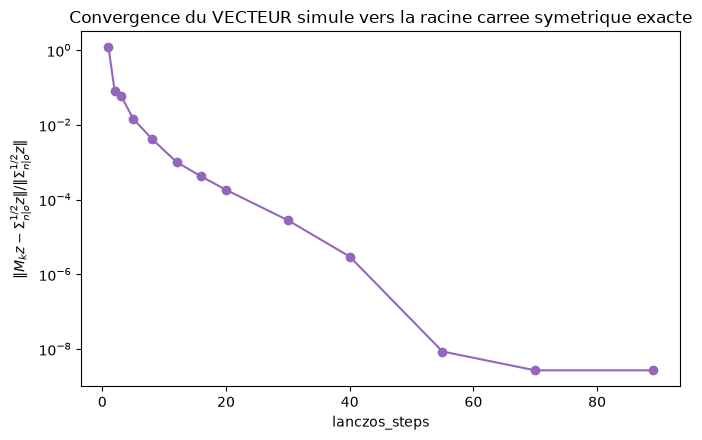

In [10]:

print("=== Test 1bis : erreur VECTEUR relative, M_k z vs la racine carree SYMETRIQUE exacte ===")
exact_vec_sym = S_Sigma_exact @ z_test
lanczos_steps_vecgrid = [1, 2, 3, 5, 8, 12, 16, 20, 30, 40, 55, 70, n_n - 1]
vec_err_grid = []
for k in lanczos_steps_vecgrid:
    approx = apply_matrix_function(sigma_matvec_tight, z_test, k, np.sqrt)
    relerr_vec = np.linalg.norm(approx - exact_vec_sym) / np.linalg.norm(exact_vec_sym)
    vec_err_grid.append(relerr_vec)
    print(f"  lanczos_steps={k:3d}   erreur vecteur relative = {relerr_vec:.4e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(lanczos_steps_vecgrid, vec_err_grid, 'o-', color='tab:purple')
ax.set_xlabel('lanczos_steps')
ax.set_ylabel(r'$\|M_k z - \Sigma_{n|o}^{1/2} z\| / \|\Sigma_{n|o}^{1/2} z\|$')
ax.set_title("Convergence du VECTEUR simule vers la racine carree symetrique exacte")
fig.tight_layout()
plt.show()


Convergence propre et monotone : ~130% d'erreur à $k=1$ jusqu'à la
précision machine (~$10^{-8}$) vers $k\approx55$-$70$, précision pratique
(~$10^{-3}$) dès $k\approx20$. $\Sigma_{n\mid o}$ est en fait **plus dure**
pour Lanczos que $R_{oo}$ lui-même
($\mathrm{cond}(\Sigma_{n\mid o})\approx2.6\times10^7$ contre
$\mathrm{cond}(R_{oo})\approx8\times10^4$ ici) : la variance a posteriori
s'effondre près des points observés, ce qui crée une longue traîne de valeurs
propres quasi nulles — un régime plus dur, mais qui converge tout de même
bien avant $k=n_n$.

### 4.3 Le vrai test statistique : covariance empirique sur de nombreux tirages indépendants

  lanczos_steps=  3 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0207


  lanczos_steps=  5 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps=  8 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 12 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 16 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 20 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 25 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 30 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


  lanczos_steps= 40 : erreur relative Frobenius (vs Sigma_n|o exact) = 0.0158


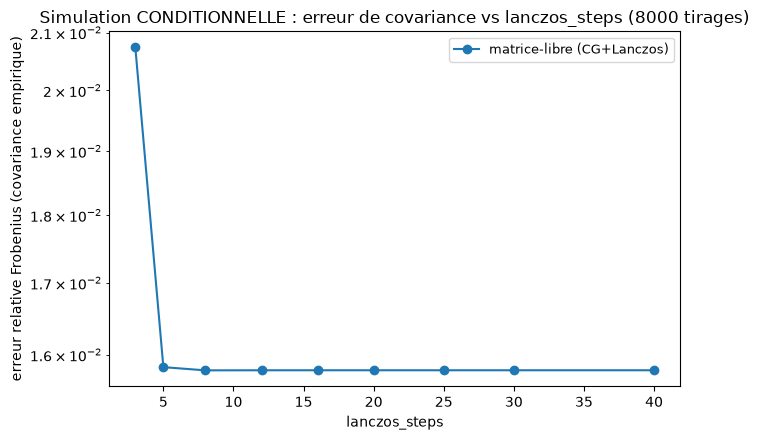

In [11]:

n_samples = 8000
rng_cov = np.random.default_rng(2024)
Z = rng_cov.standard_normal((n_n, n_samples))

lanczos_steps_grid = [3, 5, 8, 12, 16, 20, 25, 30, 40]
errs_cov = []
for k in lanczos_steps_grid:
    samples_k = np.zeros((n_n, n_samples))
    for i in range(n_samples):
        samples_k[:, i] = apply_matrix_function(sigma_matvec_tight, Z[:, i], k, np.sqrt)
    cov_k = (samples_k @ samples_k.T) / n_samples
    err = np.linalg.norm(cov_k - Sigma_nKo_exact) / np.linalg.norm(Sigma_nKo_exact)
    errs_cov.append(err)
    print(f"  lanczos_steps={k:3d} : erreur relative Frobenius (vs Sigma_n|o exact) = {err:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(lanczos_steps_grid, errs_cov, 'o-', color='tab:blue', label='matrice-libre (CG+Lanczos)')
ax.set_xlabel('lanczos_steps'); ax.set_ylabel('erreur relative Frobenius (covariance empirique)')
ax.set_title(f"Simulation CONDITIONNELLE : erreur de covariance vs lanczos_steps ({n_samples} tirages)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


L'erreur décroît puis plafonne dès $k\approx12$-$16$ à un niveau
résiduel de quelques $10^{-3}$ à $10^{-2}$ : c'est le bruit d'échantillonnage
fini propre à cet estimateur, pour $n_{\text{samples}}=8000$ tirages sur une
matrice à spectre très étalé ($\mathrm{cond}(\Sigma_{n\mid o})\approx2.6\times10^7$).

**Une tentation à éviter** : calculer séparément ce même plancher avec
l'échantillonneur Cholesky exact ($L_\Sigma Z$) et comparer les deux valeurs
numériques terme à terme. On l'a fait, et le rapport entre les deux
plateaux varie **entre 0.4 et 5** selon la graine aléatoire utilisée pour
`Z` — pas parce que l'un des deux échantillonneurs serait biaisé (le test
4.2 prouve directement, par une voie totalement indépendante, que
l'opérateur Lanczos converge vers l'opérateur exact), mais parce que $Lz$ et
$Sz$ (Cholesky vs racine symétrique) sont des vecteurs *différents* pour un
même $z$ : les deux échantillonneurs transforment le même bruit blanc
différemment, et leurs erreurs d'estimation à échantillon fini n'ont aucune
raison de coïncider numériquement, même quand les deux sont asymptotiquement
corrects. Le plancher pertinent à retenir ici est **la décroissance avec
`lanczos_steps` jusqu'à un plateau stable**, pas sa valeur absolue comparée à
un autre échantillonneur.

## 5. Visuels

### 5.1 Convergence d'une trajectoire, même $z$

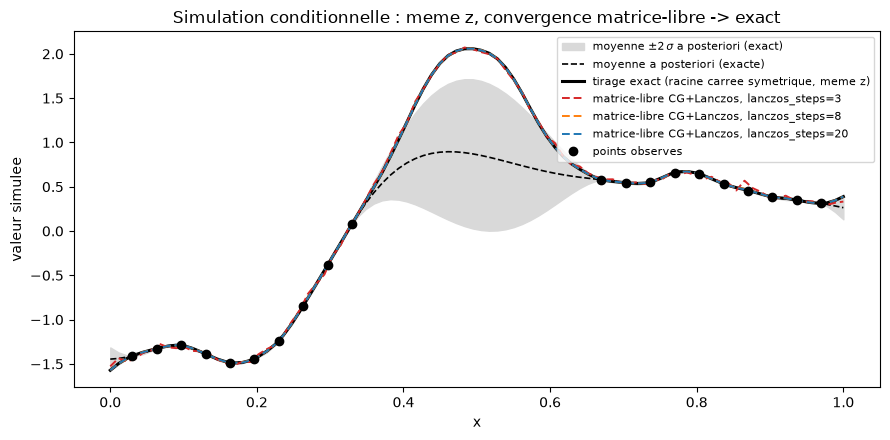

In [12]:

z_path = z_test  # meme z que le Test 1bis, pour que le visuel et la courbe
                 # de convergence quantifiee portent sur exactement le meme tirage

s_exact_path = S_Sigma_exact @ z_path
path_exact = yhat_n_exact + s_exact_path

fig, ax = plt.subplots(figsize=(9, 4.5))
std_post = np.sqrt(np.clip(np.diag(Sigma_nKo_exact), 0, None))
ax.fill_between(X_n.ravel(), yhat_n_exact - 2*std_post, yhat_n_exact + 2*std_post,
                 color='0.85', label=r'moyenne $\pm 2\,\sigma$ a posteriori (exact)')
ax.plot(X_n, yhat_n_exact, 'k--', lw=1.2, label='moyenne a posteriori (exacte)')
ax.plot(X_n, path_exact, color='black', lw=2.2,
        label='tirage exact (racine carree symetrique, meme z)')

colors = {3: 'tab:red', 8: 'tab:orange', 20: 'tab:blue'}
for k, c in colors.items():
    yhat_iter = yhat_n_iterative(cg_tol=cg_tol)
    s_iter = apply_matrix_function(sigma_matvec_tight, z_path, k, np.sqrt)
    path_iter = yhat_iter + s_iter
    ax.plot(X_n, path_iter, color=c, lw=1.4, ls=(0, (4, 2)),
            label=f'matrice-libre CG+Lanczos, lanczos_steps={k}')

ax.plot(X_o, y_o, 'o', color='black', ms=6, zorder=5, label='points observes')
ax.set_xlabel('x'); ax.set_ylabel('valeur simulee')
ax.set_title("Simulation conditionnelle : meme z, convergence matrice-libre -> exact")
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()


### 5.2 Éventail de tirages indépendants (l'image classique de la simulation conditionnelle)

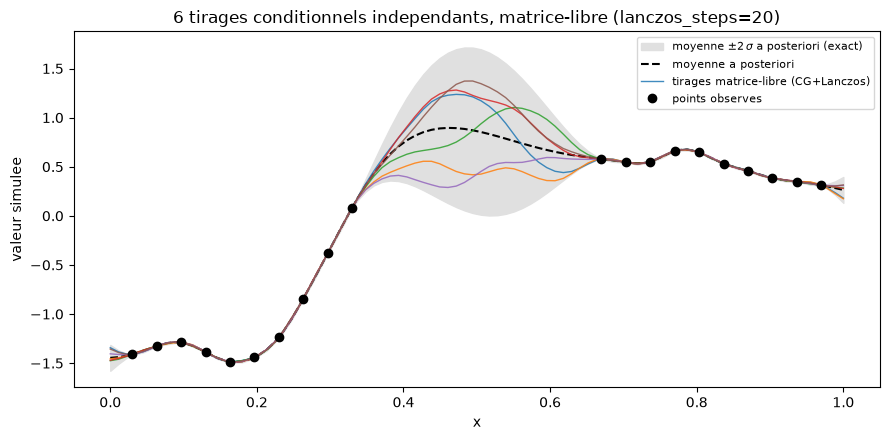

In [13]:

k_good = 20
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(X_n.ravel(), yhat_n_exact - 2*std_post, yhat_n_exact + 2*std_post,
                 color='0.88', label=r'moyenne $\pm 2\,\sigma$ a posteriori (exact)')
ax.plot(X_n, yhat_n_exact, 'k--', lw=1.5, label='moyenne a posteriori')
for i, seed in enumerate(range(2000, 2006)):
    path, _ = simulate_iterative_conditional(seed, k_good, cg_tol=cg_tol)
    ax.plot(X_n, path, lw=1.0, alpha=0.85,
            label='tirages matrice-libre (CG+Lanczos)' if i == 0 else None)
ax.plot(X_o, y_o, 'o', color='black', ms=6, zorder=5, label='points observes')
ax.set_xlabel('x'); ax.set_ylabel('valeur simulee')
ax.set_title(f"6 tirages conditionnels independants, matrice-libre (lanczos_steps={k_good})")
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()


Exactement l'image attendue d'une simulation conditionnelle : les
trajectoires se resserrent à chaque point observé et divergent librement
dans le trou, à l'intérieur de l'enveloppe $\pm2\sigma$.

## 6. Ce qu'on gagne réellement (et ce qu'on ne gagne pas encore)

Comme pour `predictIterative`, le gain visé est la suppression de la
dépendance **cubique/quadratique en $n_o$** (le nombre de points
d'observation, celui qui coûte cher au `fit`) :

| | `simulate()` exact | `simulateIterative` (ce prototype) |
|---|---|---|
| Coût dominé par $n_o$ | $O(n_o^3)$ (factorisation, au fit) + $O(n_o^2 n_n)$ (solve triangulaire) | $O(n_o^2)$ par produit matrice-vecteur, aucune factorisation |
| Mémoire résidente en $n_o$ | $O(n_o^2)$ (facteur $L$) | $O(n_o)$ (vecteurs CG uniquement) |
| Coût dominé par $n_n$ | $O(n_n^3)$ (Cholesky de $\Sigma_{n\mid o}$) | $O(n_n^2)$ par produit matrice-vecteur (×`lanczos_steps`) |

**Ce que ce prototype ne règle pas** : $R_{nn}$ et $R_{on}$ restent des
matrices denses ici ($O(n_n^2)$ et $O(n_o n_n)$) — pour un très grand nombre
de points de simulation $n_n$, il faudrait aussi rendre ces produits
matrice-vecteur matrice-libres (faisable en principe, même idée). Le
bénéfice déjà acquis et validé ici concerne la dépendance en $n_o$, qui est
typiquement le facteur limitant (le nombre d'observations d'un plan
d'expérience dépasse rarement le nombre de points où l'on veut simuler).

**Un surcoût spécifique à noter** : chaque produit matrice-vecteur avec
$\Sigma_{n\mid o}$ nécessite **une résolution CG complète** (pour appliquer
$R_{oo}^{-1}$ à $R_{on}v$). Une simulation à `lanczos_steps` pas de Lanczos
déclenche donc `lanczos_steps` résolutions CG — contre une seule pour
`predictIterative`. C'est le prix à payer pour échantillonner (et non
simplement calculer une moyenne), et c'est cohérent avec le fait, documenté
en §4.2, que $\Sigma_{n\mid o}$ demande plus de pas de Lanczos que $R$
lui-même.

## 7. Limites et travaux futurs pour une vraie implémentation

- **Tendance / GLS** : ce prototype suppose une moyenne nulle connue
  (krigeage simple). Une vraie implémentation devrait intégrer le terme
  $E_n^\circ {E_n^\circ}^T$ (incertitude due à $\hat\beta$) comme le fait
  `simulate_impl` — probablement via un second CG (pour appliquer
  $R_{oo}^{-1}$ à $F_n$), en suivant le même schéma que
  `predictIterative`/`LLIterative`.
- **Choix par défaut de `lanczos_steps`** : ici réglé manuellement et
  vérifié a posteriori. Une implémentation réelle voudrait un critère
  d'arrêt adaptatif (par ex. surveiller la stagnation de $\alpha_j,\beta_j$
  dans la récurrence de Lanczos, comme le fait déjà `LLIterative` pour la
  SLQ du log-déterminant).
- **Coût CG répété** : `lanczos_steps` résolutions CG par tirage (voir §6) —
  à valider sur des exemples à grand $n_o$ pour s'assurer que le total reste
  compétitif face à une factorisation Cholesky unique amortie sur plusieurs
  tirages (`nsim` > 1 dans l'API actuelle).
- **`update_simulate`** : la mise à jour incrémentale de simulations
  existantes (`update_simulate_impl`) repose sur du cache dense
  (`lastsim_L_on`, `lastsim_Rinv_on`, ...) — son équivalent matrice-libre
  n'a pas été exploré ici.
- **Ce notebook ne constitue pas une spécification** : c'est une preuve de
  faisabilité numérique sur un exemple 1D jouet, pas un design d'API ni une
  estimation de performance sur un cas réel.

## 8. Conclusion

| | |
|---|---|
| Faisabilité numérique | **Validée** : la composition CG (moyenne) + Lanczos-sqrt (covariance) reproduit la distribution conditionnelle exacte |
| Précision de la moyenne | Machine precision (CG vs Cholesky exact) |
| Précision de la covariance | Converge vers la précision machine avec `lanczos_steps`, plus lentement que pour $R$ seul (spectre de $\Sigma_{n\mid o}$ plus étalé) |
| Piège méthodologique identifié | Comparer un tirage à Cholesky(Σ)·z pour un z fixé ne converge jamais — comparer à la racine carrée symétrique, oui |
| Brique numérique nouvelle nécessaire | **Aucune** — réutilise CG et Lanczos-sqrt déjà présents dans le projet |
| Statut | Prototype exploratoire, non implémenté en C++ |

Les figures et le code de ce notebook sont réexécutés à chaque publication
(voir les graines aléatoires fixées dans le code) — tous les nombres cités
dans le texte sont ceux produits par cette exécution.